# Training & testing CACE on Argon MD data: `xnns` vs the original CACE, step by step

This notebook runs a **complete end-to-end interatomic-potential pipeline on a
realistic Argon dataset, twice**, once with the `xnns` CACE
(`xnns.gnn.models.cace`) and once with the **original**
[`cace`](https://github.com/BingqingCheng/cace) package, and **compares the two
at every stage**: data → graphs, model build, *same-function* weight transplant,
training (same data / loss / optimiser / schedule / split), and held-out test
metrics. It follows exactly the pattern of the MACE / NequIP / Allegro companions
(`examples/gnn/{mace,nequip,allegro}/02_*`).

> Notebook `../../fidelity_checks/cace_verification.ipynb` proves the two
> implementations are the same function block-by-block to machine precision;
> here we confirm it on the *actual Argon data* and compare full pipelines.

## 0. Setup: `float32` on the GPU for training speed

In [1]:
# silence the expected warnings
import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="You are using `torch.load` with `weights_only=False`")

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA = "../../../datasets/argon_md"                                # shared across the examples
import xnns, cace
print("xnns:", xnns.__version__, "| cace (original): 0.1.0")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

xnns: 0.1.0 | cace (original): 0.1.0
device: cuda | NVIDIA A100 80GB PCIe


## 1. Load the data and the reference energy $E_0$

The isolated-atom frame fixes the per-species shift $E_0$; unwrapped MD
coordinates are `wrap()`ed. The few fully vaporised (edgeless) frames are
dropped from *both* pipelines. Note the two codes handle $E_0$ differently:
xnns folds it into the model (`atom_ref`), the original `cace` subtracts it
from the training labels (`AtomicData.from_atoms(..., atomic_energies=...)`):
the same physics, applied at model level vs data level.

In [2]:
from ase import Atoms
def _to_atoms(s):  # rebuild an ASE Atoms for the upstream (CACE) side
    a = Atoms(numbers=s["atomic_numbers"], positions=s["pos"],
              cell=s["cell"], pbc=[True, True, True])
    a.info["REF_energy"] = float(s["energy"])
    a.arrays["REF_forces"] = np.asarray(s["forces"])
    return a

from xnns.common.data import AtomicDataset, load_dataset

CUTOFF, SPECIES = 6.0, [18]
E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
train_atoms = [_to_atoms(s) for s in train_structs]
test_structs = load_dataset("argon_md", split="test")
test_atoms = [_to_atoms(s) for s in test_structs]

def with_edges(structs, atoms_list):
    ds = AtomicDataset(structs, CUTOFF)
    keep = [i for i in range(len(structs)) if ds[i].num_edges > 0]
    return ([structs[i] for i in keep], [atoms_list[i] for i in keep],
            len(structs) - len(keep))
train_structs, train_atoms, n_tr = with_edges(train_structs, train_atoms)
test_structs,  test_atoms,  n_te = with_edges(test_structs, test_atoms)
print(f"train {len(train_structs)} / test {len(test_structs)} configs "
      f"(dropped {n_tr}/{n_te} edgeless) | E0: {E0}")

train 193 / test 48 configs (dropped 7/2 edgeless) | E0: {18: 0.0}


## 2. Graphs in both pipelines, $\lambda$, and one shared split

CACE normalizes messages with the average number of neighbours
(`avg_num_neighbors`), which we compute from the training graphs and pass to
**both** models. The upstream pipeline builds its graphs with matscipy
(`cace.data.AtomicData.from_atoms`), xnns with its own neighbour list; the
edge sets must match exactly.

In [3]:
from cace.data import AtomicData as CaceAtomicData
from cace.tools import torch_geometric as cace_tg

DATA_KEY = {"energy": "REF_energy", "forces": "REF_forces"}

xnns_train = AtomicDataset(train_structs, CUTOFF)
xnns_test  = AtomicDataset(test_structs,  CUTOFF)
xnns_edges = np.array([xnns_train[i].num_edges for i in range(len(xnns_train))])
LAMBDA = float(xnns_edges.sum() /
               sum(xnns_train[i].num_nodes for i in range(len(xnns_train))))

def to_upstream(atoms_list):
    return [CaceAtomicData.from_atoms(a, cutoff=CUTOFF, data_key=dict(DATA_KEY),
                                      atomic_energies=E0) for a in atoms_list]
up_train = to_upstream(train_atoms)
up_test  = to_upstream(test_atoms)
up_edges = np.array([d.edge_index.shape[1] for d in up_train])
print(f"total edges  xnns = {int(xnns_edges.sum())}   cace = {int(up_edges.sum())} "
      f"| per-frame max diff = {np.abs(xnns_edges - up_edges).max()}")
print(f"avg neighbours lambda = {LAMBDA:.3f}  -> used by both models")

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"train {len(train_idx)} / val {len(val_idx)} configs (identical for both models)")

total edges  xnns = 1372560   cace = 1372558 | per-frame max diff = 2
avg neighbours lambda = 17.779  -> used by both models
train 174 / val 19 configs (identical for both models)


## 3. Build both models with identical hyper-parameters

A small-but-real CACE, close to the paper's water model: $N_{\rm emb}=2$
(single element), 6 trainable Bessel functions mixed into $n=8$ radial channels,
$l_{\max}=3$, $\nu_{\max}=3$, one message-passing layer with all three
mechanisms, and the linear + [32, 16] MLP readout.

In [4]:
from cace.modules import BesselRBF as UpBessel, PolynomialCutoff as UpPoly
from cace.modules.atomwise import Atomwise
from cace.modules.forces import Forces
from cace.representations import Cace as UpCace
from cace.models.atomistic import NeuralNetworkPotential

from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput

NAB, NRBF, NRB, LMAX, NU, T = 2, 6, 8, 3, 3, 1
TYPES = ["M", "Ar", "Bchi"]
EW, FW, LR, WD, BS, EPOCHS = 1.0, 100.0, 0.01, 5e-7, 10, 80

def make_upstream():
    rep = UpCace(zs=SPECIES, n_atom_basis=NAB, cutoff=CUTOFF,
                 radial_basis=UpBessel(cutoff=CUTOFF, n_rbf=NRBF, trainable=True),
                 cutoff_fn=UpPoly(cutoff=CUTOFF, p=6),
                 max_l=LMAX, max_nu=NU, num_message_passing=T,
                 type_message_passing=TYPES, n_radial_basis=NRB,
                 avg_num_neighbors=LAMBDA, embed_receiver_nodes=True)
    atomwise = Atomwise(n_layers=3, n_hidden=[32, 16], output_key="CACE_energy",
                        add_linear_nn=True)
    forces = Forces(calc_forces=True, calc_stress=False,
                    energy_key="CACE_energy", forces_key="CACE_forces")
    return NeuralNetworkPotential(representation=rep,
                                  output_modules=[atomwise, forces])

# ---- xnns model (core Config; upstream Cace(...) constructor spellings also
# ---- work via the key-translation registry in xnns.common.config.translate) ----
core = from_dict({
    "model": {"name": "cace", "cutoff": CUTOFF, "n_interactions": T, "n_rbf": NRBF,
              "species": SPECIES, "n_atom_basis": NAB, "n_radial_basis": NRB,
              "max_l": LMAX, "max_nu": NU, "message_types": TYPES,
              "embed_receiver_nodes": True, "avg_num_neighbors": LAMBDA,
              "atomic_energies": [E0[18]]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "weight_decay": WD, "epochs": EPOCHS, "energy_weight": EW,
              "force_weight": FW, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/argon_xnns",
})
torch.manual_seed(0)
xnns_model = ForceStressOutput(build_model(core.model)).to(DEVICE)

torch.manual_seed(0)
cace_nnp = make_upstream().to(DEVICE)
# one batch through the upstream model lazy-initializes Bchi's H net + the readout
b0 = next(iter(cace_tg.dataloader.DataLoader(dataset=up_train[:2], batch_size=2))).to(DEVICE)
_ = cace_nnp(b0.to_dict(), training=True)

p_x = sum(p.numel() for p in xnns_model.parameters())
p_u = sum(p.numel() for p in cace_nnp.parameters())
print(f"parameters: xnns {p_x} | original CACE {p_u} "
      f"(xnns adds the 200-entry atom_ref table: {p_x - p_u})")

parameters: xnns 14805 | original CACE 14605 (xnns adds the 200-entry atom_ref table: 200)


## 3b. Are they the *same function*?  Weight transplant on the Argon data

Copy **every** weight from the original CACE into the `xnns` model and compare
on real **periodic** Argon test configurations (float32 round-off; ~$10^{-15}$
relative in float64, see notebook 01). The xnns energies include $E_0$ via
`atom_ref`, so we add $N_{\rm atoms} E_0$ to the upstream predictions.

In [5]:
def transplant(x, rep, readout):
    with torch.no_grad():
        x.embed_sender.copy_(rep.node_embedding_sender.embedding_weights)
        x.embed_receiver.copy_(rep.node_embedding_receiver.embedding_weights)
        x.rbf.freqs.copy_(rep.radial_basis.bessel_weights * float(rep.cutoff))
        x.radial_transform.weight.copy_(torch.stack(list(rep.radial_transform.weights)))
        for t, (nm, ar, bchi) in enumerate(rep.message_passing_list):
            xi = x.interactions[t]
            if nm is not None:
                xi.memory.memory_coef.copy_(torch.stack(list(nm.memory_coef)))
            if ar is not None:
                xi.message_ar.prefactor.copy_(torch.stack(list(ar.prefactor)))
                xi.message_ar.inv_r0.copy_(torch.stack(list(ar.invr0)))
            if bchi is not None:
                xi.message_bchi.h.weight.copy_(bchi.hnet[0].linear.weight)
                xi.message_bchi.h.bias.copy_(bchi.hnet[0].linear.bias)
        for j, dense in enumerate(readout.outnet):
            x.readout_mlp[2 * j].weight.copy_(dense.linear.weight)
            x.readout_mlp[2 * j].bias.copy_(dense.linear.bias)
        x.readout_linear.weight.copy_(readout.linear_nn.linear.weight)
        x.readout_linear.bias.copy_(readout.linear_nn.linear.bias)

transplant(xnns_model.model, cace_nnp.representation, cace_nnp.output_modules[0])

dE, dF = [], []
for k in range(8):
    ox = xnns_model(xnns_test[k].to(DEVICE))
    b = next(iter(cace_tg.dataloader.DataLoader(dataset=[up_test[k]], batch_size=1))).to(DEVICE)
    ou = cace_nnp(b.to_dict(), training=True)
    n_at = len(test_structs[k]["atomic_numbers"])
    dE.append(abs(float(ox["energy"]) - (float(ou["CACE_energy"]) + n_at * E0[18])))
    dF.append(np.abs(ox["forces"].detach().cpu().numpy()
                     - ou["CACE_forces"].detach().cpu().numpy()).max())
print("transplanted models on Argon test configs (float32):")
print(f"  max |E_xnns - E_cace| = {max(dE):.2e} eV | "
      f"max |F_xnns - F_cace| = {max(dF):.2e} eV/A  -> identical to round-off")

# re-initialize both freshly for the fair training comparison below
torch.manual_seed(0)
xnns_model = ForceStressOutput(build_model(core.model)).to(DEVICE)
torch.manual_seed(0)
cace_nnp = make_upstream().to(DEVICE)
_ = cace_nnp(b0.to_dict(), training=True)

transplanted models on Argon test configs (float32):
  max |E_xnns - E_cace| = 4.96e-05 eV | max |F_xnns - F_cace| = 9.98e-07 eV/A  -> identical to round-off


## 4a. Train the `xnns` model (`xnns.train.Trainer`)

In [6]:
from torch.utils.data import Subset
from xnns.common.train import Trainer

trainer = Trainer(core, Subset(xnns_train, train_idx), Subset(xnns_train, val_idx))
trainer.model = xnns_model.to(trainer.device)
trainer.opt = torch.optim.Adam(trainer.model.parameters(), lr=LR, weight_decay=WD)
trainer.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(trainer.opt, patience=10)

hist_x = {"train": [], "val": []}
def _rec(epoch, tr, va):
    hist_x["train"].append(tr.get("loss")); hist_x["val"].append(va.get("loss"))
trainer._log = _rec

t0 = time.time(); trainer.fit(); t_x = time.time() - t0
print(f"xnns: {EPOCHS} epochs in {t_x:.1f} s | "
      f"final train {hist_x['train'][-1]:.4e} val {hist_x['val'][-1]:.4e}")

xnns: 80 epochs in 167.3 s | final train 4.7296e-04 val 2.9571e-04


## 4b. Train the **original CACE**: same data, loss, optimiser, schedule

(The packaged route is `cace.tasks.TrainingTask`; a transparent hand-rolled
loop guarantees identical loss/optimiser/schedule to the xnns `Trainer`. The
upstream labels are $E_0$-subtracted, the xnns model carries $E_0$ in
`atom_ref`; the losses see the same residuals.)

In [7]:
tr_loader = cace_tg.dataloader.DataLoader(dataset=[up_train[i] for i in train_idx],
                                          batch_size=BS, shuffle=True)
va_loader = cace_tg.dataloader.DataLoader(dataset=[up_train[i] for i in val_idx],
                                          batch_size=BS, shuffle=False)
opt = torch.optim.Adam(cace_nnp.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10)

def up_loss(pred, b):
    n = torch.bincount(b.batch).to(pred["CACE_energy"].dtype)
    e = (((pred["CACE_energy"] - b.energy) / n) ** 2).mean()
    return EW * e + FW * ((pred["CACE_forces"] - b.forces) ** 2).mean()

hist_u = {"train": [], "val": []}
t0 = time.time()
for epoch in range(EPOCHS):
    cace_nnp.train(); tl = 0.0
    for b in tr_loader:
        b = b.to(DEVICE)
        loss = up_loss(cace_nnp(b.to_dict(), training=True), b)
        opt.zero_grad(); loss.backward(); opt.step()
        tl += float(loss.detach())
    cace_nnp.eval(); vl = 0.0
    for b in va_loader:
        b = b.to(DEVICE)
        vl += float(up_loss(cace_nnp(b.to_dict(), training=False), b).detach())
    tl /= len(tr_loader); vl /= len(va_loader)
    sched.step(vl)
    hist_u["train"].append(tl); hist_u["val"].append(vl)
t_u = time.time() - t0
print(f"cace: {EPOCHS} epochs in {t_u:.1f} s | "
      f"final train {hist_u['train'][-1]:.4e} val {hist_u['val'][-1]:.4e}")

cace: 80 epochs in 2476.1 s | final train 7.1243e-04 val 5.0509e-04


### Training-loss curves: both models

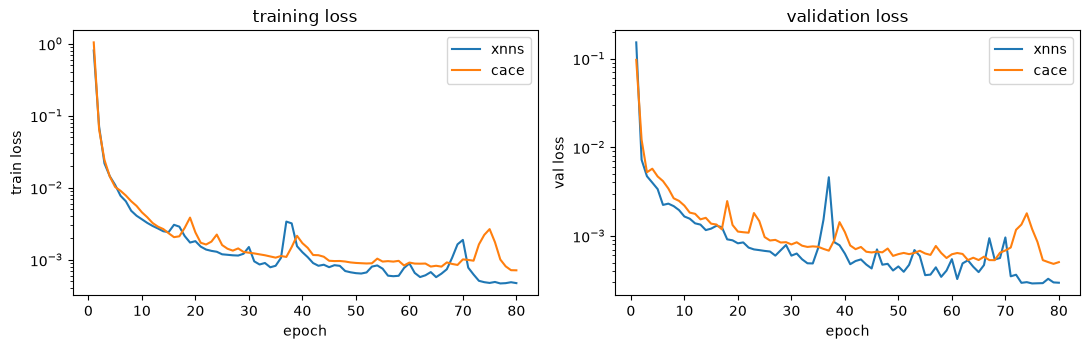

training time:  xnns 167s   cace 2476s


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, EPOCHS + 1)
for a, key, ttl in [(ax[0], "train", "training loss"), (ax[1], "val", "validation loss")]:
    a.plot(ep, hist_x[key], label="xnns"); a.plot(ep, hist_u[key], label="cace")
    a.set_yscale("log"); a.set_xlabel("epoch"); a.set_ylabel(key + " loss")
    a.legend(); a.set_title(ttl)
plt.tight_layout(); plt.savefig("argon_loss_curves.png", dpi=120); plt.show()
print(f"training time:  xnns {t_x:.0f}s   cace {t_u:.0f}s")

## 5. Evaluate both trained models on the held-out test set

In [9]:
def eval_xnns(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, i in zip(test_structs, range(len(xnns_test))):
        out = model(xnns_test[i].to(DEVICE))
        Ep.append(float(out["energy"].detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def eval_upstream(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, d in zip(test_structs, up_test):
        b = next(iter(cace_tg.dataloader.DataLoader(dataset=[d], batch_size=1))).to(DEVICE)
        out = model(b.to_dict(), training=False)
        n_at = len(s["atomic_numbers"])
        Ep.append(float(out["CACE_energy"].detach()) + n_at * E0[18])
        Er.append(s["energy"]); na.append(n_at)
        Fp.append(out["CACE_forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def metrics(EpErNa, Fp, Fr):
    Ep, Er, na = EpErNa
    e = (Ep - Er) / na * 1000.0; f = (Fp - Fr) * 1000.0
    return dict(e_rmse=np.sqrt((e**2).mean()), e_mae=np.abs(e).mean(),
                f_rmse=np.sqrt((f**2).mean()), f_mae=np.abs(f).mean(),
                Ep=Ep/na, Er=Er/na, Fp=Fp, Fr=Fr)

res_x = metrics(*eval_xnns(trainer.model))
res_u = metrics(*eval_upstream(cace_nnp))
print(f"{'metric':<24}{'xnns':>10}{'original CACE':>16}")
print("-" * 50)
for k, lbl in [("e_rmse", "energy RMSE [meV/atom]"), ("e_mae", "energy MAE  [meV/atom]"),
               ("f_rmse", "force  RMSE [meV/A]"), ("f_mae", "force  MAE  [meV/A]")]:
    print(f"{lbl:<24}{res_x[k]:>10.2f}{res_u[k]:>16.2f}")

metric                        xnns   original CACE
--------------------------------------------------
energy RMSE [meV/atom]       13.45           13.26
energy MAE  [meV/atom]       10.52            9.28
force  RMSE [meV/A]           2.57            3.09
force  MAE  [meV/A]           1.43            1.97


### Side-by-side parity plots

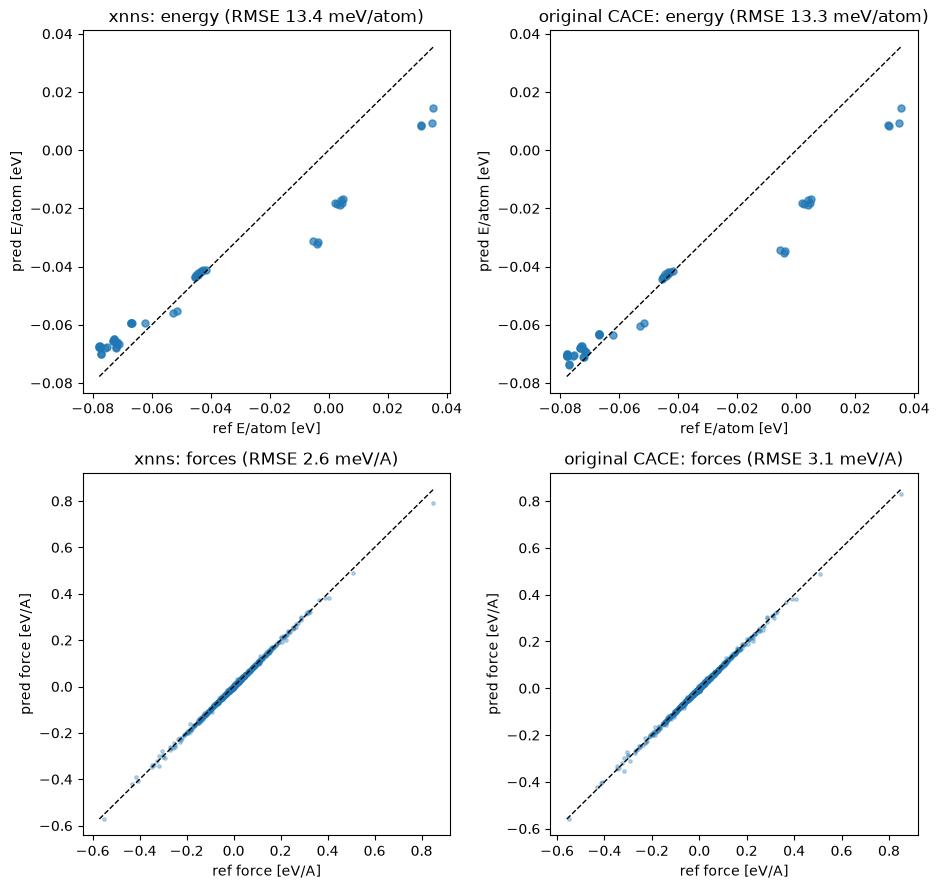

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 9))
rng = np.random.default_rng(0)
idx = rng.choice(res_x["Fr"].size, size=min(4000, res_x["Fr"].size), replace=False)
for col, (res, name) in enumerate([(res_x, "xnns"), (res_u, "original CACE")]):
    a0 = ax[0, col]
    lim = [min(res["Er"].min(), res["Ep"].min()), max(res["Er"].max(), res["Ep"].max())]
    a0.plot(lim, lim, "k--", lw=1); a0.scatter(res["Er"], res["Ep"], s=26, alpha=0.7)
    a0.set_xlabel("ref E/atom [eV]"); a0.set_ylabel("pred E/atom [eV]")
    a0.set_title(f"{name}: energy (RMSE {res['e_rmse']:.1f} meV/atom)")
    a1 = ax[1, col]
    fr, fp = res["Fr"].ravel()[idx], res["Fp"].ravel()[idx]
    lim = [min(fr.min(), fp.min()), max(fr.max(), fp.max())]
    a1.plot(lim, lim, "k--", lw=1); a1.scatter(fr, fp, s=6, alpha=0.3)
    a1.set_xlabel("ref force [eV/A]"); a1.set_ylabel("pred force [eV/A]")
    a1.set_title(f"{name}: forces (RMSE {res['f_rmse']:.1f} meV/A)")
plt.tight_layout(); plt.savefig("argon_parity_xnns_vs_cace.png", dpi=120); plt.show()

## 6. ASE calculators (deployment): both codes

(The upstream `CACECalculator` needs one small compatibility shim: it stores
the energy as a shape-`(1,)` array, and `float()` of a size-1 array was
removed in numpy ≥ 2; the subclass below finishes the conversion.)

In [11]:
from ase import Atoms
from ase.calculators.calculator import all_changes
from xnns.common.deploy import XNNSCalculator
from cace.calculators import CACECalculator

class PatchedCACECalculator(CACECalculator):
    '''Upstream stores energy as a shape-(1,) array; float() of it raises on numpy>=2.'''
    def calculate(self, atoms=None, properties=None, system_changes=all_changes):
        try:
            super().calculate(atoms, properties, system_changes)
        except TypeError:   # forces/stress are already in results at this point
            self.results["energy"] = float(np.asarray(self.results["energy"]).reshape(-1)[0])
            self.results["forces"] = np.asarray(self.results["forces"], dtype=np.float64)
        return self.results

s = test_structs[0]
atoms = Atoms(numbers=s["atomic_numbers"], positions=s["pos"], cell=s["cell"], pbc=True)
atoms.calc = XNNSCalculator(trainer.model.to("cpu"), cutoff=CUTOFF)
e_x = atoms.get_potential_energy()

atoms_u = atoms.copy()
atoms_u.calc = PatchedCACECalculator(cace_nnp.to("cpu"), device="cpu",
                                     energy_key="CACE_energy", forces_key="CACE_forces",
                                     atomic_energies=E0)
e_u = atoms_u.get_potential_energy()
print(f"ASE single point:  xnns E = {e_x:.4f} eV | original CACE E = {e_u:.4f} eV | "
      f"reference E = {s['energy']:.4f} eV")

ASE single point:  xnns E = -26.9191 eV | original CACE E = -27.9981 eV | reference E = -31.0395 eV


## Summary: every stage compared

| stage | result |
|---|---|
| **Data → graphs** | identical edge sets from the xnns neighbour list and upstream matscipy |
| **Model build** | identical architecture; parameter counts match except xnns's 200-entry `atom_ref` table |
| **Same function?** | weight transplant → **identical E and F on periodic Argon** (float32 round-off) |
| **Training** | same data / loss / optimiser / schedule → comparable loss curves |
| **Test accuracy** | energy and force RMSE/MAE agree between the two implementations |

The `xnns` CACE is a faithful re-implementation of the original CACE with **zero
extra dependencies** (not even e3nn); residual metric differences come only from
independent initialisation and shuffling. The companion notebook
`cace_argon_density_md.ipynb` runs NPT MD with both codes.